# Week 5 — Machine Learning Fundamentals & Regression

## From prepared data to a predictive model

In the previous weeks we explored, cleaned, and prepared data. In this notebook we enter the **modelling phase**.

We will build and interpret a **linear regression** model for predicting house prices. This is supposed to be an exersice for you to learn how to use linear regression for your own data and questsions.

### Learning goals
- Distinguish **features** (`X`) from the **target** (`y`)
- Implement the train/test split
- Fit a linear regression model
- Interpret coefficients and predictions
- Understand residuals, loss, and least squares
- Distinguish a **loss** (used for training) from an **evaluation metric** (used for judging)
- Explore generalisation, underfitting and overfitting
- Calculate and interpret basic regression metrics

> **Important:** This notebook introduces evaluation metrics, but detailed model evaluation and comparison will be covered later in the course.

## 1. The modelling workflow

Our basic supervised-learning workflow is:

**Dataset → Features `X` + Target `y` → Train/Test Split → Train Model → Predictions → Error → Evaluate Generalisation**

Today our question is:

> **Can we predict house price from characteristics of a house?**

For more details, review our slides material.

## 2. Load the libraries

We will use:
- `pandas` for tabular data
- `matplotlib` for visualisation
- `scikit-learn` for splitting data, fitting models, and calculating metrics

In [23]:
%pip install jinja2

     -------------------------------------- 134.9/134.9 kB 4.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: c:\Users\Igaba\.pyenv\pyenv-win\versions\3.11.3\python.exe -m pip install --upgrade pip


In [5]:
%pip install numpy pandas matplotlib scikit-learn

  Using cached pandas-3.0.6-cp311-cp311-win_amd64.whl (9.9 MB)
  Using cached matplotlib-3.11.2-cp311-cp311-win_amd64.whl (9.3 MB)
  Using cached scikit_learn-1.9.1-cp311-cp311-win_amd64.whl (8.3 MB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: c:\Users\Igaba\.pyenv\pyenv-win\versions\3.11.3\python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
     ---------------------------------------- 9.9/9.9 MB 3.1 MB/s eta 0:00:00
     ---------------------------------------- 9.3/9.3 MB 4.2 MB/s eta 0:00:00
     ---------------------------------------- 8.3/8.3 MB 4.2 MB/s eta 0:00:00
     -------------------------------------- 348.0/348.0 kB 3.6 MB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 1.6/1.6 MB 5.0 MB/s eta 0:00:00
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl (70 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl (7.2 MB)
     -------------------------------------- 126.4/126.4 kB 3.7 MB/s eta 0:00:00
     ---------------------------------------- 36.6/36.6 MB 4.3 MB/s eta 0:00:00
     -------------------------------------- 306.1/306.1 kB 4.7 MB/s eta 0:00:00
     -------------------------------------- 474.0/474.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: c:\Users\Igaba\.pyenv\pyenv-win\versions\3.11.3\python.exe -m pip install --upgrade pip


## 3. Load the teaching dataset

We will use a prepared **synthetic** (not real!) dataset stored in `data/house_prices.csv`. Each row represents a house, and the file contains 120 examples. 

The columns describe:

- `area_m2`: floor area in square metres
- `bedrooms`: number of bedrooms
- `distance_to_city_km`: distance from the city centre
- `age_years`: age of the building
- `price_eur`: house price — **our target**

The data were generated once using a known relationship: the price starts at €120,000, increases by €3,800 per square metre and €15,000 per bedroom, and decreases by €9,500 per kilometre from the city centre and €1,200 per year of age. Random noise was added so that prices do not follow the formula exactly. Because the data are synthetic, we know this underlying relationship and can compare it with what the model learns. Real datasets do not usually give us the true formula.

This dataset is for teaching only, not real-world property analysis.

In [7]:
df = pd.read_csv('../data/house_prices.csv')
df.head()

,area_m2,bedrooms,distance_to_city_km,age_years,price_eur
0,149.5,4,9.3,39.5,591804
1,104.2,2,13.1,25.1,378530
2,160.9,3,9.2,46.5,720057
3,139.1,3,6.5,40.3,633609
4,57.7,1,5.9,20.0,230703


## 4. Inspect the dataset

Before modelling, we should still do basic checks. Modelling does not replace data understanding.

In [8]:
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isna().sum())

df.describe().round(2)

Shape: (120, 5)

Data types:
area_m2                float64
bedrooms                 int64
distance_to_city_km    float64
age_years              float64
price_eur                int64
dtype: object

Missing values:
area_m2                0
bedrooms               0
distance_to_city_km    0
age_years              0
price_eur              0
dtype: int64


,area_m2,bedrooms,distance_to_city_km,age_years,price_eur
count,120.00,120.00,120.00,120.00,120.00
mean,112.33,2.54,7.55,30.44,474794.12
std,36.95,1.06,4.15,18.00,164232.82
min,46.00,1.00,0.80,0.30,157107.00
25%,81.58,2.00,3.90,14.00,347789.00
50%,108.50,3.00,7.70,31.85,456850.50
75%,143.25,3.00,11.38,46.35,597898.25
max,176.70,5.00,14.70,59.90,791735.00


## 5. Features `X` and target `y`

We want to predict `price_eur`. Therefore:

- **Target `y`** = `price_eur`
- **Features `X`** = the variables we use to predict price

For our first model, we use **one feature only: floor area**. This lets us see exactly what simple linear regression is doing.

In [9]:
X = df[['area_m2']]
y = df['price_eur']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (120, 1)
y shape: (120,)


## 6. Explore the relationship

Before fitting a model, visualise the relationship between the feature and target.

This simple scatter plot works because we are looking at one feature and one target. With many features, we cannot show all dimensions in a single 2D plot. We can inspect selected feature–target plots or pairwise plots, but each shows only part of the picture; the model can still use all the features together.

**Question:** Does a straight line seem like a reasonable first approximation?

I would say yes for the graph displayed as there is a clear linear trend upwards from left to right 

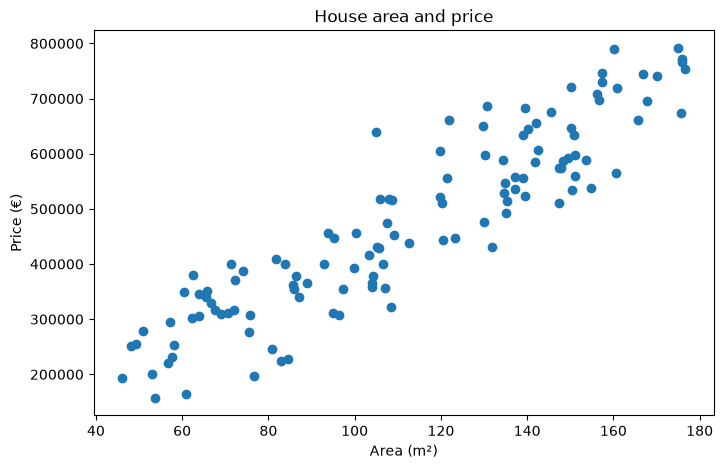

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df['area_m2'], df['price_eur'])
plt.xlabel('Area (m²)')
plt.ylabel('Price (€)')
plt.title('House area and price')
plt.show()

## 7. Train vs. test data

We split the observations into two groups:

- **Training data:** used to learn the model parameters
- **Test data:** kept separate so that we can assess performance on unseen observations

Here, `test_size=0.2` assigns 20% of the observations to the test set and the remaining 80% to training. This 80/20 split is a common starting point: it leaves most examples available for learning while reserving enough to get a basic check on unseen data. It is a practical convention, not a fixed rule; the right split depends on the dataset and the task. With our 120 examples, that means 96 training examples and 24 test examples.

We use `random_state=42` so that everyone gets the same split when running the notebook.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training observations:', len(X_train))
print('Test observations:', len(X_test))

Training observations: 96
Test observations: 24


## 8. Train a linear regression model

Our model is:

$$\hat{y} = b_0 + b_1x$$

The model learns two parameters:

- `b0`: intercept
- `b1`: coefficient / slope

We use `LinearRegression` from scikit-learn. It finds the parameters with **ordinary least squares**. We look at what that means in Section 13.

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Intercept:', model.intercept_)
print('Coefficient:', model.coef_[0])

Intercept: 11966.259782726178
Coefficient: 4093.4875190393386


## 9. Interpret the model

The model has the form:

$$\hat{y} = b_0 + b_1 \times \text{area}$$

The coefficient tells us how the **predicted** price changes when the area increases by one square metre.

**Important:** This is an interpretation of the model's association. It does not establish that increasing the area *causes* the price to increase.

In [13]:
print(f'Model equation: price = {model.intercept_:,.0f} + {model.coef_[0]:,.0f} × area_m2')
print(f'Predicted change for +10 m²: €{10 * model.coef_[0]:,.0f}')

Model equation: price = 11,966 + 4,093 × area_m2
Predicted change for +10 m²: €40,935


### Is the intercept meaningful?

Formally, the intercept is the predicted price of a house with **0 m²** of floor area. No such house exists, and our data only covers about 45–180 m².

The intercept is needed to position the line, but interpreting it literally means **extrapolating** far outside the data. Always check whether "all features = 0" is a sensible situation before interpreting the intercept.

**Question:** The one-feature slope is not the same as the true 3,800 €/m². Why might that be? (Hint: which other feature is closely related to area?)

it's not the same because the model is omitting a variable similar to area, possibly it is the number of bedrooms

## 10. Make predictions

The trained model can now make predictions for observations it has not seen during training.

In [14]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'area_m2': X_test['area_m2'].values,
    'actual_price': y_test.values,
    'predicted_price': y_pred.round(0).astype(int)
})

results.head(10)

,area_m2,actual_price,predicted_price
0,157.4,729319,656281
1,83.9,399672,355410
2,57.7,230703,248160
3,150.4,534039,627627
4,108.0,518672,454063
5,130.7,686447,546985
6,76.6,197732,325527
7,95.1,447254,401257
8,104.0,365578,437689
9,81.8,409966,346814


## 11. Visualise the fitted regression line

Let's plot the training observations and the line learned by the model.

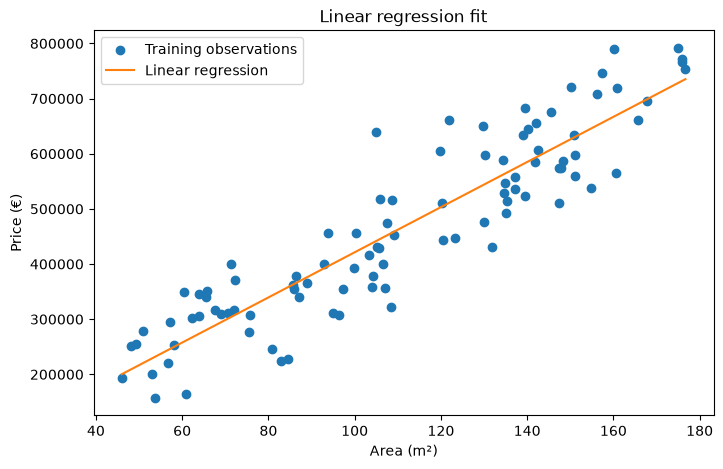

In [15]:
x_line = pd.DataFrame({'area_m2': np.linspace(df['area_m2'].min(), df['area_m2'].max(), 200)})
y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_train['area_m2'], y_train, label='Training observations')
plt.plot(x_line['area_m2'], y_line, color='C1', label='Linear regression')
plt.xlabel('Area (m²)')
plt.ylabel('Price (€)')
plt.title('Linear regression fit')
plt.legend()
plt.show()

## 12. Residuals

A residual is:

$$e_i = y_i - \hat{y}_i$$

Let's calculate the residuals for the test observations.

In [16]:
results['residual'] = y_test.values - y_pred
results['residual'] = results['residual'].round(0).astype(int)
results.head(10)

,area_m2,actual_price,predicted_price,residual
0,157.4,729319,656281,73038
1,83.9,399672,355410,44262
2,57.7,230703,248160,-17457
3,150.4,534039,627627,-93588
4,108.0,518672,454063,64609
5,130.7,686447,546985,139462
6,76.6,197732,325527,-127795
7,95.1,447254,401257,45997
8,104.0,365578,437689,-72111
9,81.8,409966,346814,63152


### Visualising residuals

A residual is the vertical distance between an observation and the model's prediction. Ideally, residuals scatter randomly around 0 with no visible pattern.

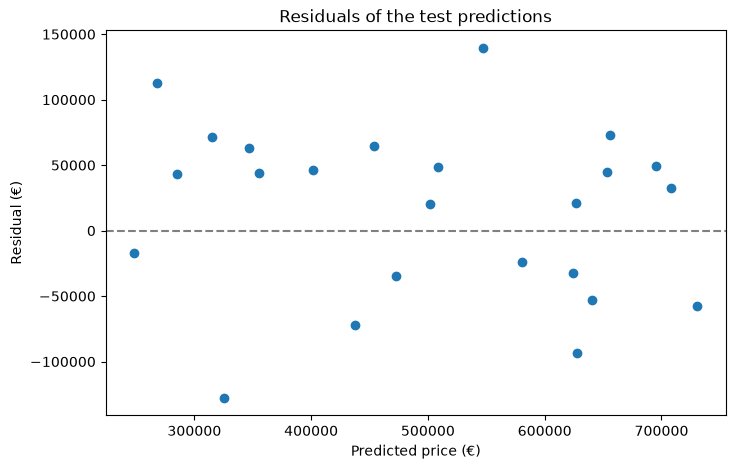

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(results['predicted_price'], results['residual'])
plt.axhline(0, linestyle='--', color='grey')
plt.xlabel('Predicted price (€)')
plt.ylabel('Residual (€)')
plt.title('Residuals of the test predictions')
plt.show()

## 13. How does the model choose a line?

A model's predictions will not usually match every house price exactly. The difference between an actual price and a predicted price is called a **residual** (introduced above).

To choose a line, linear regression looks for one that keeps the residuals small overall. In ordinary least squares, larger errors count more because residuals are squared before being added together. This total is called the **sum of squared errors (SSE)**. You do not need to calculate or optimise it by hand: `LinearRegression` does that when we call `.fit()`.

The code below calculates the training SSE for the fitted model. It is a measure of how closely the model fits the training examples; by itself, it does not tell us how well the model predicts new examples.

In [18]:
train_predictions = model.predict(X_train)
train_residuals = y_train.values - train_predictions
train_sse = np.sum(train_residuals ** 2)

print(f'Training sum of squared errors: {train_sse:,.0f}')

Training sum of squared errors: 431,761,507,738


## 14. Regression evaluation

After fitting a model, **evaluation** means checking how close its predictions are to the actual house prices. We do this with numerical summaries called **metrics**. Training metrics show how well the model fits examples it learned from; test metrics show how well it predicts examples held aside from training. Comparing them gives us an initial sense of how well the model may generalise to new data.

We use four common regression metrics:

- **MAE:** average absolute prediction error
- **MSE:** average squared prediction error
- **RMSE:** square root of MSE, in the original target units
- **R²:** compares the model with a simple baseline that always predicts the average price

### Loss vs. evaluation metric

| | Loss | Evaluation metric |
|---|---|---|
| Used by | the algorithm | us |
| When | during training | after training |
| Data | training set | training or test set |
| Purpose | choose the parameters | summarise prediction performance |

The same formula (e.g. MSE) can play both roles. What differs is **who uses it, when, and on which data**. We compute the metrics on **both** sets so that we can compare them.

In [24]:
def regression_metrics(y_true, y_hat):
    mse = mean_squared_error(y_true, y_hat)
    return {
        'MAE (€)': mean_absolute_error(y_true, y_hat),
        'MSE (€²)': mse,
        'RMSE (€)': np.sqrt(mse),
        'R²': r2_score(y_true, y_hat),
    }

metrics_1f = pd.DataFrame({
    'Training': regression_metrics(y_train, model.predict(X_train)),
    'Test': regression_metrics(y_test, y_pred),
})
metrics_1f.style.format('{:,.3f}', subset=pd.IndexSlice[['R²'], :]) \
                .format('{:,.0f}', subset=pd.IndexSlice[['MAE (€)', 'MSE (€²)', 'RMSE (€)'], :])

,Training,Test
MAE (€),"54,638","57,772"
MSE (€²),"4,497,515,706","4,371,699,603"
RMSE (€),"67,064","66,119"
R²,0.833,0.819


**Questions:**
- Are the training and test results similar or very different? What would a big gap tell you?


there is not a very noticeable difference between the metrics for the traaining and test data, and the test is slightly better than the training data. a big gap would suggest overfitting.
- Which metric would you report to someone buying a house? Why is MSE hard to communicate?


I would use MAE because it uses the same units as money and shows the average error. MSE is hard to communicate because noone will understand what is a euro squared and how it relates to anything.

## 15. Next step: add more features

Our first model used only `area_m2`. Next, extend it to **multiple linear regression** by using all four house features:

$$\hat{y} = b_0 + b_1x_1 + b_2x_2 + b_3x_3 + b_4x_4$$

### Build and compare the model
1. Create a new `X` containing the four features.
2. Keep `price_eur` as `y`.
3. Split the data into training and test sets.
4. Fit a new `LinearRegression` model.
5. Print the coefficients.
6. Calculate MAE, RMSE, and R² on the test data.
7. Compare the result with the one-feature model.

A worked example follows. Try implementing these steps yourself first if you like, then run and study the solution.

> **Note:** We use the same `random_state=42`, so both models are tested on **exactly the same houses**. Without that, a difference in scores could come from a different test set rather than a better model.

In [25]:
features = ['area_m2', 'bedrooms', 'distance_to_city_km', 'age_years']

X_multi = df[features]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_m = model_multi.predict(X_test_m)

comparison = pd.DataFrame({
    'Area only (test)': regression_metrics(y_test, y_pred),
    'Four features (test)': regression_metrics(y_test_m, y_pred_m),
})
comparison.drop(index='MSE (€²)').round(3)

,Area only (test),Four features (test)
MAE (€),57771.677,32010.575
RMSE (€),66118.829,44094.720
R²,0.819,0.919


### Did the model recover the truth?

Because we generated the data, we can compare the learned parameters with the true ones.

In [26]:
learned = pd.Series(
    [model_multi.intercept_, *model_multi.coef_],
    index=['intercept', *features]
)
pd.DataFrame({'True': pd.Series(TRUE), 'Learned': learned.round(0)})

NameError: name 'TRUE' is not defined

**Questions:**
- Which parameters are recovered well, and which less well? Why can't the model recover them *exactly*?
- Compare the area coefficient here with the one from the one-feature model. Which is closer to the truth?

### Holding other features constant

Area and bedrooms are strongly related: bigger houses tend to have more bedrooms.

In [ ]:
print(f"Correlation between area and bedrooms: {df['area_m2'].corr(df['bedrooms']):.2f}")

In the one-feature model, the area coefficient also "absorbs" part of the bedroom effect, because area and bedrooms move together.

In the multiple model, each coefficient is interpreted **holding the other included features constant**. The bedroom coefficient answers: *for two houses with the same floor area, distance and age, how much does one extra bedroom change the predicted price?* An extra bedroom in the same floor area mostly means smaller rooms.

### Should we remove highly correlated features?

Not automatically. When two features are strongly correlated, it can be difficult for the model to separate their individual effects, so the coefficients may be less stable or harder to interpret—even when predictions are still useful. Consider removing or combining a feature if it mostly duplicates another and a simpler model is preferable; compare performance on held-out data before deciding.

## 16. Do more features always help?

So far, adding features improved the test results. But those features genuinely matter for price.

What happens if we add features that are **pure noise**, i.e. random numbers with no relationship to price at all?

In [ ]:
noise_rng = np.random.default_rng(0)
n_noise = 10

X_noisy = X_multi.copy()
for k in range(n_noise):
    X_noisy[f'noise_{k}'] = noise_rng.normal(size=len(X_noisy))

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42
)
model_noisy = LinearRegression().fit(X_train_n, y_train_n)

pd.DataFrame({
    'Training R²': [model_multi.score(X_train_m, y_train_m), model_noisy.score(X_train_n, y_train_n)],
    'Test R²':     [model_multi.score(X_test_m, y_test_m),   model_noisy.score(X_test_n, y_test_n)],
}, index=['4 real features', f'4 real + {n_noise} noise features']).round(3)

The noise features have no real relationship with house price. However, by chance, some values line up with the training prices, and the model can use those accidental patterns to fit the training examples a little better. Here, training R² rises from 0.928 to 0.935, while test R² falls from 0.919 to 0.907.


## 17. Underfitting and overfitting: a visual example

House prices in our dataset follow a straight-line relationship, so a linear model is a good fit. To see under- and overfitting clearly, we switch to a small toy dataset with a **curved** relationship. This is the same data as the visual example on the slides.

We make linear regression more flexible by adding powers of the feature: $x, x^2, x^3, \dots$ This is still **linear** regression, because the model is linear in its parameters $b_0, b_1, b_2, \dots$ It is just applied to engineered features.

- **Degree 1:** a straight line
- **Degree 3:** a gentle curve
- **Degree 15:** a very flexible curve

In [ ]:
toy_rng = np.random.default_rng(39)
true_curve = lambda x: np.sin(2 * np.pi * x)

x_toy_train = np.sort(np.clip(np.linspace(0, 1, 18) + toy_rng.normal(0, 0.02, 18), 0, 1))
y_toy_train = true_curve(x_toy_train) + toy_rng.normal(0, 0.25, 18)
x_toy_test = np.sort(toy_rng.uniform(x_toy_train.min(), x_toy_train.max(), 18))
y_toy_test = true_curve(x_toy_test) + toy_rng.normal(0, 0.25, 18)

def poly_model(degree):
    return make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    ).fit(x_toy_train[:, None], y_toy_train)

def rmse(m, x, y_true):
    return np.sqrt(mean_squared_error(y_true, m.predict(x[:, None])))

x_grid = np.linspace(x_toy_train.min(), x_toy_train.max(), 500)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (degree, label) in zip(axes, [(1, 'Underfitting'), (3, 'Good fit'), (15, 'Overfitting')]):
    m = poly_model(degree)
    ax.plot(x_grid, m.predict(x_grid[:, None]), color='C2', lw=2, label='Model')
    ax.scatter(x_toy_train, y_toy_train, color='C3', label='Training data')
    ax.scatter(x_toy_test, y_toy_test, facecolors='none', edgecolors='k', label='Test data')
    ax.set_ylim(-1.9, 1.9)
    ax.set_title(f'{label} (degree {degree})\n'
                 f'train RMSE {rmse(m, x_toy_train, y_toy_train):.2f} · '
                 f'test RMSE {rmse(m, x_toy_test, y_toy_test):.2f}')
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(loc='lower left')
plt.tight_layout()
plt.show()

### Training vs. test error across model complexity

In [ ]:
degrees = range(1, 16)
train_err = [rmse(poly_model(d), x_toy_train, y_toy_train) for d in degrees]
test_err  = [rmse(poly_model(d), x_toy_test,  y_toy_test)  for d in degrees]

plt.figure(figsize=(9, 5))
plt.plot(degrees, train_err, 'o-', label='Training error')
plt.plot(degrees, test_err,  'o-', label='Test error')
plt.yscale('log')
plt.xticks(list(degrees))
plt.xlabel('Model complexity (polynomial degree)')
plt.ylabel('RMSE (log scale)')
plt.title('Training vs. test error')
plt.legend()
plt.show()

- **Training error** keeps falling as the model gets more flexible. A flexible model can always fit the training data better.
- **Test error** first falls (the model captures the real pattern), then rises (the model starts fitting noise).

Too simple → **underfitting**. Too complex → **overfitting**. The best model sits in between. We will return to model complexity and **regularisation** later in the course.

# Key Takeaways

- **Regression** predicts a numerical target: features `X` are inputs, and `y` is the value to predict.
- Linear regression learns a relationship from training data. Its coefficients describe associations, not necessarily causes.
- A **residual** is the difference between an actual value and a prediction. Ordinary least squares fits the model by keeping squared residuals small.
- Test data and metrics such as MAE, RMSE, and R² help us check how well predictions may work for unseen examples.
- A model can fit training data well but perform poorly on new data; adding features or complexity does not always help.

### Next step

Next session, we will predict **categories** using classification.